# GIBridge — GI Cancer Subtype Classifier (Stage 1)
## Deliberately simple 4-modality MLP fusion — not a transformer

### Why simpler than OncoBridge-MMCAT:
| Setting | OncoBridge-MMCAT (pan-cancer) | GIBridge (this notebook) | Why |
|---|---|---|---|
| Samples | 7,912 (22/32 classes) | ~1,457 (6 GI classes) | ~5.4x less data — a transformer would overfit |
| Per-modality encoder | CNN + 6-layer Transformer + CLS token | 2-layer MLP | No sequence modeling needed at this scale |
| Cross-modal fusion | 4-layer cross-attention + gated fusion | Concatenation | Fewer params; classifier head learns the combination |
| embed_dim | 384 | 128 | Model size matched to data size |
| Gene caps (mRNA/CNV/Mut/Meth) | 9000/3500/2500/6000 | 4000/1750/1250/3000 | Halved — curb dimensionality vs. sample-count ratio |
| Params | tens of millions | a few hundred thousand | Avoid overfitting a 6-class, ~1.5k-sample task |

### What's kept from OncoBridge (proven, not architecture-dependent):
- Modality-correct scaling: mRNA -> StandardScaler, CNV -> MaxAbsScaler, Mutation/Methylation -> no scaling
- Variance-based auto-k gene selection (train-only, no leakage)
- Per-gene `GeneImportanceLayer` gate (cheap, interpretable — a single elementwise multiply, not a
  transformer component)
- CE loss + class weights + label smoothing (handles cholangiocarcinoma's n=36)
- Mixup augmentation, OneCycleLR, AdamW

### Input:
Expects `mrna_gi.parquet`, `cnv_gi.parquet`, `mut_gi.parquet`, `meth_gi.parquet`, `labels_gi.parquet`
produced by the companion GI data-analysis notebook. Target column: `labels['_gi_class']` (6 classes,
colon + rectum already merged into "colorectal cancer").

### Before running:
Update `CONFIG['mrna_path']` etc. below to the Kaggle dataset slug where you uploaded the GI parquet
outputs from the data-analysis notebook.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MaxAbsScaler
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, matthews_corrcoef, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import VarianceThreshold
import copy, time, math, warnings, gc
warnings.filterwarnings('ignore')
# =============================================================================
#  CENTRAL CONFIG -- only change things here
# =============================================================================
CONFIG = {
    # -- Data paths (outputs of the GI data-analysis notebook) --------------
    # UPDATE THE DATASET SLUG once you've uploaded mrna_gi.parquet etc. to Kaggle
    'mrna_path'  : '/kaggle/input/datasets/proutkarshtiwari/gastric-cancer-data/mrna_gi.parquet',
    'cnv_path'   : '/kaggle/input/datasets/proutkarshtiwari/gastric-cancer-data/cnv_gi.parquet',
    'mut_path'   : '/kaggle/input/datasets/proutkarshtiwari/gastric-cancer-data/mut_gi.parquet',
    'meth_path'  : '/kaggle/input/datasets/proutkarshtiwari/gastric-cancer-data/meth_gi.parquet',
    'label_path' : '/kaggle/input/datasets/proutkarshtiwari/gastric-cancer-data/labels_gi.parquet',
    'label_col'  : '_gi_class',   # 6-class target (colon+rectum already merged)

    # -- Gene selection: auto-k by variance coverage, halved caps vs OncoBridge --
    'auto_k_coverage': 0.85,
    'mrna_max_k' : 4000,
    'cnv_max_k'  : 1750,
    'mut_max_k'  : 1250,
    'meth_max_k' : 3000,

    # -- Architecture: simple per-modality MLP + concat fusion --------------
    'embed_dim'  : 128,
    'hidden_dim' : 256,
    'dropout'    : 0.30,
    'gate_init'  : 1.5,     # GeneImportanceLayer sigmoid gate init (same as OncoBridge)

    # -- Training -------------------------------------------------------------
    'epochs'      : 150,
    'batch_size'  : 32,
    'lr'          : 3e-4,
    'weight_decay': 1e-4,
    'patience'    : 20,
    'label_smoothing': 0.05,
    'clip_grad'   : 1.0,
    'warmup_frac' : 0.10,
    'checkpoint'  : 'gibridge_stage1_best.pt',
    'num_workers' : 2,
    'use_amp'     : True,

    # -- Loss: CE + class weights ---------------------------------------------
    'max_class_weight': 8.0,

    # -- Mixup (lighter than OncoBridge -- smaller model needs less regularisation) --
    'use_mixup'  : True,
    'mixup_prob' : 0.30,
    'mixup_alpha': 0.2,

    # -- Split ------------------------------------------------------------------
    'use_test_set': True,    # True -> 70/15/15
    'seed'        : 42,
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True
    for i in range(N_GPUS):
        gb = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)} -- {gb:.1f} GB')

print(f'Primary device: {DEVICE}')
print(f'Architecture:   per-modality MLP encoders + concat fusion (no transformer)')


  GPU 0: Tesla T4 -- 15.6 GB
  GPU 1: Tesla T4 -- 15.6 GB
Primary device: cuda
Architecture:   per-modality MLP encoders + concat fusion (no transformer)


In [2]:
# =============================================================================
#  DATA LOADING
# =============================================================================
print('Loading 4 GI modalities from parquet...')
t0 = time.time()

mrna_df  = pd.read_parquet(CONFIG['mrna_path'])
cnv_df   = pd.read_parquet(CONFIG['cnv_path'])
mut_df   = pd.read_parquet(CONFIG['mut_path'])
meth_df  = pd.read_parquet(CONFIG['meth_path'])
label_df = pd.read_parquet(CONFIG['label_path'])

print(f'  mRNA:        {mrna_df.shape}')
print(f'  CNV:         {cnv_df.shape}')
print(f'  Mutation:    {mut_df.shape}')
print(f'  Methylation: {meth_df.shape}')
print(f'  Labels:      {label_df.shape}')
print(f'  Loaded in {time.time()-t0:.1f}s')

# -- Encode labels (6 GI classes) --------------------------------------------
le = LabelEncoder()
y  = le.fit_transform(label_df[CONFIG['label_col']])
CONFIG['num_classes'] = len(le.classes_)

X = {
    'mrna': mrna_df.values.astype(np.float32),
    'cnv' : cnv_df.values.astype(np.float32),
    'mut' : mut_df.values.astype(np.float32),
    'meth': meth_df.values.astype(np.float32),
}
del mrna_df, cnv_df, mut_df, meth_df
gc.collect()

print(f'\nClasses: {CONFIG["num_classes"]}')
print('Class distribution:')
for i, cls in enumerate(le.classes_):
    n = int(np.sum(y == i))
    bar = chr(9608) * max(1, n // 5)
    print(f'  {i}. {cls:<35} n={n:4d}  {bar}')


Loading 4 GI modalities from parquet...
  mRNA:        (1457, 15816)
  CNV:         (1457, 15816)
  Mutation:    (1457, 15816)
  Methylation: (1457, 15816)
  Labels:      (1457, 2)
  Loaded in 5.8s

Classes: 6
Class distribution:
  0. cholangiocarcinoma                  n=  36  ███████
  1. colorectal cancer                   n= 357  ███████████████████████████████████████████████████████████████████████
  2. esophageal carcinoma                n= 181  ████████████████████████████████████
  3. liver hepatocellular carcinoma      n= 348  █████████████████████████████████████████████████████████████████████
  4. pancreatic adenocarcinoma           n= 168  █████████████████████████████████
  5. stomach adenocarcinoma              n= 367  █████████████████████████████████████████████████████████████████████████


In [3]:
# -- Stratified split: 70/15/15 (or 80/20) -----------------------------------
idx = np.arange(len(y))

if CONFIG['use_test_set']:
    tr_idx, tmp = train_test_split(idx, test_size=0.30, stratify=y,
                                   random_state=CONFIG['seed'])
    vl_idx, te_idx = train_test_split(tmp, test_size=0.50, stratify=y[tmp],
                                      random_state=CONFIG['seed'])
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)} | Test={len(te_idx)}')
else:
    tr_idx, vl_idx = train_test_split(idx, test_size=0.20, stratify=y,
                                      random_state=CONFIG['seed'])
    te_idx = None
    print(f'Split: Train={len(tr_idx)} | Val={len(vl_idx)}')

print('\nPer-class counts in each split:')
for i, cls in enumerate(le.classes_):
    tr_n = int((y[tr_idx] == i).sum())
    vl_n = int((y[vl_idx] == i).sum())
    te_n = int((y[te_idx] == i).sum()) if te_idx is not None else 0
    print(f'  {cls:<35} train={tr_n:3d}  val={vl_n:3d}  test={te_n:3d}')


Split: Train=1019 | Val=219 | Test=219

Per-class counts in each split:
  cholangiocarcinoma                  train= 25  val=  5  test=  6
  colorectal cancer                   train=250  val= 54  test= 53
  esophageal carcinoma                train=127  val= 27  test= 27
  liver hepatocellular carcinoma      train=243  val= 52  test= 53
  pancreatic adenocarcinoma           train=117  val= 26  test= 25
  stomach adenocarcinoma              train=257  val= 55  test= 55


In [4]:
# =============================================================================
#  GENE SELECTION -- same principled auto-k approach as OncoBridge, lower caps
#  (train-only variance, no leakage; modality-correct scaling)
# =============================================================================
MAX_K = {
    'mrna': CONFIG['mrna_max_k'],
    'cnv' : CONFIG['cnv_max_k'],
    'mut' : CONFIG['mut_max_k'],
    'meth': CONFIG['meth_max_k'],
}

SCALER_TYPE = {
    'mrna': 'standard',
    'cnv' : 'maxabs',
    'mut' : 'none',
    'meth': 'none',
}

def select_and_scale(X_full, split_indices, coverage, max_k, scaler_type, tag):
    X_tr_raw = X_full[split_indices[0]]
    X_vl_raw = X_full[split_indices[1]]
    X_te_raw = X_full[split_indices[2]] if split_indices[2] is not None else None

    vt = VarianceThreshold(threshold=0.0)
    vt.fit(X_tr_raw)
    variances = vt.variances_

    sorted_var = np.sort(variances)[::-1]
    total_var  = sorted_var.sum()
    cumsum     = np.cumsum(sorted_var)
    auto_k     = int(np.searchsorted(cumsum, coverage * total_var)) + 1
    k          = min(auto_k, max_k)

    top_idx = np.argsort(variances)[::-1][:k]

    X_tr = X_tr_raw[:, top_idx]
    X_vl = X_vl_raw[:, top_idx]
    X_te = X_te_raw[:, top_idx] if X_te_raw is not None else None

    if scaler_type == 'standard':
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr).astype(np.float32)
        X_vl = sc.transform(X_vl).astype(np.float32)
        X_te = sc.transform(X_te).astype(np.float32) if X_te is not None else None
        scale_note = 'StandardScaler'
    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler()
        X_tr = sc.fit_transform(X_tr).astype(np.float32)
        X_vl = sc.transform(X_vl).astype(np.float32)
        X_te = sc.transform(X_te).astype(np.float32) if X_te is not None else None
        scale_note = 'MaxAbsScaler (preserves 0)'
    else:
        X_tr = X_tr.astype(np.float32)
        X_vl = X_vl.astype(np.float32)
        X_te = X_te.astype(np.float32) if X_te is not None else None
        scale_note = 'NO SCALING (biologically correct)'

    print(f'  [{tag:4s}] auto-k={auto_k} -> capped at {k} | {scale_note}')
    return X_tr, X_vl, X_te, k


print(f'=== Gene Selection (variance coverage={CONFIG["auto_k_coverage"]*100:.0f}%) ===')
splits = (tr_idx, vl_idx, te_idx)

Xp = {}
gene_k = {}
for mod in ['mrna', 'cnv', 'mut', 'meth']:
    tr, vl, te, k = select_and_scale(
        X[mod], splits,
        coverage=CONFIG['auto_k_coverage'],
        max_k=MAX_K[mod],
        scaler_type=SCALER_TYPE[mod],
        tag=mod
    )
    Xp[mod]    = (tr, vl, te)
    gene_k[mod] = k
    CONFIG[f'num_{mod}_genes'] = k

print(f'\nSelected genes: {gene_k}')
print(f'Total features: {sum(gene_k.values()):,}')
del X; gc.collect()

# -- Class weights ------------------------------------------------------------
cw = compute_class_weight('balanced', classes=np.unique(y[tr_idx]), y=y[tr_idx])
cw = np.clip(cw, None, CONFIG['max_class_weight'])
cw_tensor = torch.FloatTensor(cw).to(DEVICE)
print(f'\nClass weights: {cw.min():.3f} - {cw.max():.3f}')
print(f'Heaviest (rarest): {le.classes_[np.argmax(cw)]} (w={cw.max():.2f})')


=== Gene Selection (variance coverage=85%) ===
  [mrna] auto-k=7104 -> capped at 4000 | StandardScaler
  [cnv ] auto-k=12769 -> capped at 1750 | MaxAbsScaler (preserves 0)
  [mut ] auto-k=8855 -> capped at 1250 | NO SCALING (biologically correct)
  [meth] auto-k=6173 -> capped at 3000 | NO SCALING (biologically correct)

Selected genes: {'mrna': 4000, 'cnv': 1750, 'mut': 1250, 'meth': 3000}
Total features: 10,000

Class weights: 0.661 - 6.793
Heaviest (rarest): cholangiocarcinoma (w=6.79)


In [5]:
class MultiOmicsDataset(Dataset):
    def __init__(self, mrna, cnv, mut, meth, labels):
        self.mrna   = torch.FloatTensor(mrna)
        self.cnv    = torch.FloatTensor(cnv)
        self.mut    = torch.FloatTensor(mut)
        self.meth   = torch.FloatTensor(meth)
        self.labels = torch.LongTensor(labels)

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        return self.mrna[i], self.cnv[i], self.mut[i], self.meth[i], self.labels[i]


def make_loader(split_key, shuffle):
    key_map = {'tr': 0, 'vl': 1, 'te': 2}
    ki = key_map[split_key]
    idx_map = {'tr': tr_idx, 'vl': vl_idx, 'te': te_idx}
    idx = idx_map[split_key]

    def get(mod):
        arr = Xp[mod][ki]
        if arr is None: arr = Xp[mod][1]
        return arr

    ds = MultiOmicsDataset(get('mrna'), get('cnv'), get('mut'), get('meth'), y[idx])
    nw = CONFIG['num_workers']
    return DataLoader(
        ds, batch_size=CONFIG['batch_size'], shuffle=shuffle,
        num_workers=nw, pin_memory=True,
        persistent_workers=(nw > 0),
        drop_last=(shuffle and len(idx) > CONFIG['batch_size']),
    )

train_loader = make_loader('tr', shuffle=True)
val_loader   = make_loader('vl', shuffle=False)
test_loader  = make_loader('te', shuffle=False) if te_idx is not None else None
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Train batches: 31 | Val batches: 7


In [6]:
# =============================================================================
#  ARCHITECTURE -- GIBridge-MLP v1
#  Deliberately simple: per-modality MLP encoder -> concatenate -> classifier.
#  No transformer, no attention, no CLS tokens, no gated fusion.
#
#  1. GeneImportanceLayer -- same as OncoBridge: a learnable per-gene sigmoid
#     gate (init 1.5 -> sigmoid=0.82, mostly open). This is NOT a transformer
#     component -- it's a single elementwise multiply, cheap and interpretable
#     (keeps the door open for the same gate-weight interpretability analysis
#     used in OncoBridge, just applied to the GI subset).
#
#  2. ModalityMLPEncoder -- 2-layer MLP per modality:
#     genes -> Linear -> BatchNorm -> GELU -> Dropout -> Linear -> BatchNorm
#     -> GELU -> Dropout -> embed_dim vector. No sequence, no attention --
#     each modality collapses straight to a fixed-size embedding.
#
#  3. Fusion -- plain concatenation of the 4 modality embeddings (4 x embed_dim).
#     No cross-attention, no learned gating -- the classifier head itself
#     learns how to combine modalities.
#
#  4. Classifier -- 4E -> 2E -> E -> num_classes, same taper ratio as
#     OncoBridge's classifier, just a smaller absolute size.
# =============================================================================

class GeneImportanceLayer(nn.Module):
    def __init__(self, num_genes, init_val=1.5):
        super().__init__()
        self.logits = nn.Parameter(torch.full((num_genes,), init_val))

    def forward(self, x):
        return x * torch.sigmoid(self.logits)


class ModalityMLPEncoder(nn.Module):
    """Per-modality encoder: GeneGate -> Linear -> BN -> GELU -> Dropout x2 -> embed_dim"""
    def __init__(self, num_genes, embed_dim, hidden_dim, dropout, gate_init=1.5):
        super().__init__()
        self.gene_gate = GeneImportanceLayer(num_genes, init_val=gate_init)
        self.net = nn.Sequential(
            nn.Linear(num_genes, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = self.gene_gate(x)
        return self.net(x)


class GIBridgeMLP(nn.Module):
    """
    GIBridge -- 4-modality MLP fusion classifier for GI cancer subtyping.

    Forward pass:
      [mRNA]  -> GeneGate -> MLP -> mrna_embed  (B, E)
      [CNV]   -> GeneGate -> MLP -> cnv_embed   (B, E)
      [Mut]   -> GeneGate -> MLP -> mut_embed   (B, E)
      [Meth]  -> GeneGate -> MLP -> meth_embed  (B, E)
          |
      Concat: [mrna | cnv | mut | meth] -> (B, 4E)
          |
      Classifier: 4E -> 2E -> E -> num_classes
    """
    def __init__(self, cfg):
        super().__init__()
        E  = cfg['embed_dim']
        H  = cfg['hidden_dim']
        D  = cfg['dropout']
        GI = cfg['gate_init']

        self.mrna_enc = ModalityMLPEncoder(cfg['num_mrna_genes'], E, H, D, GI)
        self.cnv_enc  = ModalityMLPEncoder(cfg['num_cnv_genes'],  E, H, D, GI)
        self.mut_enc  = ModalityMLPEncoder(cfg['num_mut_genes'],  E, H, D, GI)
        self.meth_enc = ModalityMLPEncoder(cfg['num_meth_genes'], E, H, D, GI)

        self.classifier = nn.Sequential(
            nn.LayerNorm(E * 4),
            nn.Linear(E * 4, E * 2),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E * 2, E),
            nn.GELU(),
            nn.Dropout(D),
            nn.Linear(E, cfg['num_classes']),
        )

    def forward(self, mrna, cnv, mut, meth):
        e_mrna = self.mrna_enc(mrna)
        e_cnv  = self.cnv_enc(cnv)
        e_mut  = self.mut_enc(mut)
        e_meth = self.meth_enc(meth)
        combined = torch.cat([e_mrna, e_cnv, e_mut, e_meth], dim=-1)
        return self.classifier(combined)


model = GIBridgeMLP(CONFIG).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'DataParallel across {N_GPUS} GPUs')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel: GIBridge-MLP v1')
print(f'  Parameters:    {n_params:,}')
print(f'  embed_dim:     {CONFIG["embed_dim"]} | hidden_dim: {CONFIG["hidden_dim"]}')
print(f'  Fusion:        concatenation (4 x {CONFIG["embed_dim"]} = {CONFIG["embed_dim"]*4})')
print(f'  Gene counts:   mRNA={CONFIG["num_mrna_genes"]} | CNV={CONFIG["num_cnv_genes"]} | '
      f'Mut={CONFIG["num_mut_genes"]} | Meth={CONFIG["num_meth_genes"]}')


DataParallel across 2 GPUs

Model: GIBridge-MLP v1
  Parameters:    2,871,702
  embed_dim:     128 | hidden_dim: 256
  Fusion:        concatenation (4 x 128 = 512)
  Gene counts:   mRNA=4000 | CNV=1750 | Mut=1250 | Meth=3000


In [7]:
criterion = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=CONFIG['label_smoothing'])
print(f'Loss: CrossEntropyLoss | class_weights: {cw.min():.2f}-{cw.max():.2f} | '
      f'label_smoothing={CONFIG["label_smoothing"]}')

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
    betas=(0.9, 0.999),
    fused=(DEVICE.type == 'cuda'),
)
print(f'Optimizer: AdamW(lr={CONFIG["lr"]}, wd={CONFIG["weight_decay"]})')

steps_per_epoch = max(1, len(train_loader))
total_steps     = steps_per_epoch * CONFIG['epochs']

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    total_steps=total_steps,
    pct_start=CONFIG['warmup_frac'],
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1000.0,
)
print(f'Scheduler: OneCycleLR | steps/epoch={steps_per_epoch} | total_steps={total_steps}')

amp_scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'])
print(f'AMP: {CONFIG["use_amp"]} | Patience: {CONFIG["patience"]}')


Loss: CrossEntropyLoss | class_weights: 0.66-6.79 | label_smoothing=0.05
Optimizer: AdamW(lr=0.0003, wd=0.0001)
Scheduler: OneCycleLR | steps/epoch=31 | total_steps=4650
AMP: True | Patience: 20


In [8]:
def mixup(mrna, cnv, mut, meth, labels, alpha=0.2):
    dist = torch.distributions.Beta(
        torch.tensor(alpha, device=DEVICE), torch.tensor(alpha, device=DEVICE))
    lam  = dist.sample().item()
    perm = torch.randperm(labels.size(0), device=DEVICE)
    return (lam * mrna + (1 - lam) * mrna[perm],
            lam * cnv  + (1 - lam) * cnv[perm],
            lam * mut  + (1 - lam) * mut[perm],
            lam * meth + (1 - lam) * meth[perm],
            labels, labels[perm], lam)


def run_epoch(model, loader, crit, opt, amp_sc, is_train, sched=None):
    model.train() if is_train else model.eval()
    tot_loss = tot_correct = tot_n = 0

    for mrna, cnv, mut, meth, labels in loader:
        mrna   = mrna.to(DEVICE, non_blocking=True)
        cnv    = cnv.to(DEVICE, non_blocking=True)
        mut    = mut.to(DEVICE, non_blocking=True)
        meth   = meth.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        do_mix = (is_train and CONFIG['use_mixup']
                  and torch.rand(1).item() < CONFIG['mixup_prob'])

        if is_train:
            opt.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            if do_mix:
                xm, xc, xu, xe, ya, yb, lam = mixup(mrna, cnv, mut, meth, labels,
                                                      CONFIG['mixup_alpha'])
                out  = model(xm, xc, xu, xe)
                loss = lam * crit(out, ya) + (1 - lam) * crit(out, yb)
            else:
                out  = model(mrna, cnv, mut, meth)
                loss = crit(out, labels)

        if is_train:
            amp_sc.scale(loss).backward()
            amp_sc.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
            amp_sc.step(opt)
            amp_sc.update()
            if sched is not None:
                sched.step()

        tot_loss += loss.item()
        preds = out.argmax(1)
        if do_mix:
            soft = lam * preds.eq(ya).float() + (1 - lam) * preds.eq(yb).float()
            tot_correct += soft.sum().item()
        else:
            tot_correct += preds.eq(labels).sum().item()
        tot_n += labels.size(0)

    return tot_loss / len(loader), 100.0 * tot_correct / tot_n


# =============================================================================
#  MAIN TRAINING LOOP
# =============================================================================
history = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']}
best_val_acc = 0.0
patience_cnt = 0
best_state   = None

W = 95
print('=' * W)
print('  GIBridge-MLP v1  |  4-Modality  |  mRNA + CNV + Mut + Methylation  |  6 GI classes')
print('=' * W)
print(f'  embed={CONFIG["embed_dim"]} | hidden={CONFIG["hidden_dim"]} | fusion=concat | '
      f'CE+CW | OneCycleLR')
print(f'  Genes: mRNA={CONFIG["num_mrna_genes"]} | CNV={CONFIG["num_cnv_genes"]} | '
      f'Mut={CONFIG["num_mut_genes"]} | Meth={CONFIG["num_meth_genes"]}')
print('=' * W)
print(f'{"Epoch":>7} | {"LR":>10} | {"TrLoss":>8} | {"TrAcc":>7} | '
      f'{"VlLoss":>7} | {"VlAcc":>7} | {"Status":<20}')
print('-' * W)

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer,
                                 amp_scaler, is_train=True, sched=scheduler)
    with torch.no_grad():
        vl_loss, vl_acc = run_epoch(model, val_loader, criterion, optimizer,
                                     amp_scaler, is_train=False)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_cnt = 0
        best_state   = copy.deepcopy(model.state_dict())
        torch.save(best_state, CONFIG['checkpoint'])
        status = 'BEST'
    else:
        patience_cnt += 1
        status = f'({patience_cnt}/{CONFIG["patience"]})'

    lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>7} | {lr:>10.6f} | {tr_loss:>8.4f} | {tr_acc:>6.2f}% | '
          f'{vl_loss:>7.4f} | {vl_acc:>6.2f}% | {status:<20}')

    if patience_cnt >= CONFIG['patience']:
        print(f'\nEarly stop at epoch {epoch}. Best val: {best_val_acc:.2f}%')
        break

print('-' * W)
print(f'Training complete. Best validation accuracy: {best_val_acc:.2f}%')


  GIBridge-MLP v1  |  4-Modality  |  mRNA + CNV + Mut + Methylation  |  6 GI classes
  embed=128 | hidden=256 | fusion=concat | CE+CW | OneCycleLR
  Genes: mRNA=4000 | CNV=1750 | Mut=1250 | Meth=3000
  Epoch |         LR |   TrLoss |   TrAcc |  VlLoss |   VlAcc | Status              
-----------------------------------------------------------------------------------------------
      1 |   0.000033 |   1.8362 |  42.82% |  1.7085 |  75.34% | BEST                
      2 |   0.000042 |   1.7447 |  68.63% |  1.5800 |  82.19% | BEST                
      3 |   0.000056 |   1.6552 |  78.25% |  1.4037 |  85.39% | BEST                
      4 |   0.000075 |   1.4818 |  82.09% |  1.1260 |  88.58% | BEST                
      5 |   0.000098 |   1.2348 |  83.89% |  0.8907 |  89.04% | BEST                
      6 |   0.000124 |   0.9431 |  86.36% |  0.6624 |  90.87% | BEST                
      7 |   0.000151 |   0.7674 |  90.28% |  0.6155 |  92.69% | BEST                
      8 |   0.000180 |  

In [9]:
def full_eval(loader, split_name):
    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for mrna, cnv, mut, meth, labels in loader:
            mrna = mrna.to(DEVICE, non_blocking=True)
            cnv  = cnv.to(DEVICE,  non_blocking=True)
            mut  = mut.to(DEVICE,  non_blocking=True)
            meth = meth.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
                out = model(mrna, cnv, mut, meth)
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    preds  = np.array(all_preds)
    labels = np.array(all_labels)

    acc = accuracy_score(labels, preds) * 100
    wf1 = f1_score(labels, preds, average='weighted')
    mf1 = f1_score(labels, preds, average='macro')
    mcc = matthews_corrcoef(labels, preds)

    print(f'\n{"="*65}')
    print(f'  {split_name} Results')
    print(f'{"="*65}')
    print(f'  Accuracy:     {acc:.2f}%')
    print(f'  Weighted F1:  {wf1:.4f}')
    print(f'  Macro F1:     {mf1:.4f}  <- fairest given class imbalance')
    print(f'  MCC:          {mcc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=le.classes_, digits=3))
    return acc, wf1, mf1, mcc, np.array(all_probs)


val_acc_final, val_wf1, val_mf1, val_mcc, val_probs = full_eval(val_loader, 'Validation')
if test_loader is not None:
    te_acc, te_wf1, te_mf1, te_mcc, te_probs = full_eval(test_loader, 'Test (held-out)')



  Validation Results
  Accuracy:     96.80%
  Weighted F1:  0.9689
  Macro F1:     0.9319  <- fairest given class imbalance
  MCC:          0.9601

                                precision    recall  f1-score   support

            cholangiocarcinoma      0.667     0.800     0.727         5
             colorectal cancer      1.000     1.000     1.000        54
          esophageal carcinoma      0.871     1.000     0.931        27
liver hepatocellular carcinoma      0.980     0.962     0.971        52
     pancreatic adenocarcinoma      1.000     1.000     1.000        26
        stomach adenocarcinoma      1.000     0.927     0.962        55

                      accuracy                          0.968       219
                     macro avg      0.920     0.948     0.932       219
                  weighted avg      0.972     0.968     0.969       219


  Test (held-out) Results
  Accuracy:     96.35%
  Weighted F1:  0.9641
  Macro F1:     0.9425  <- fairest given class imbalanc

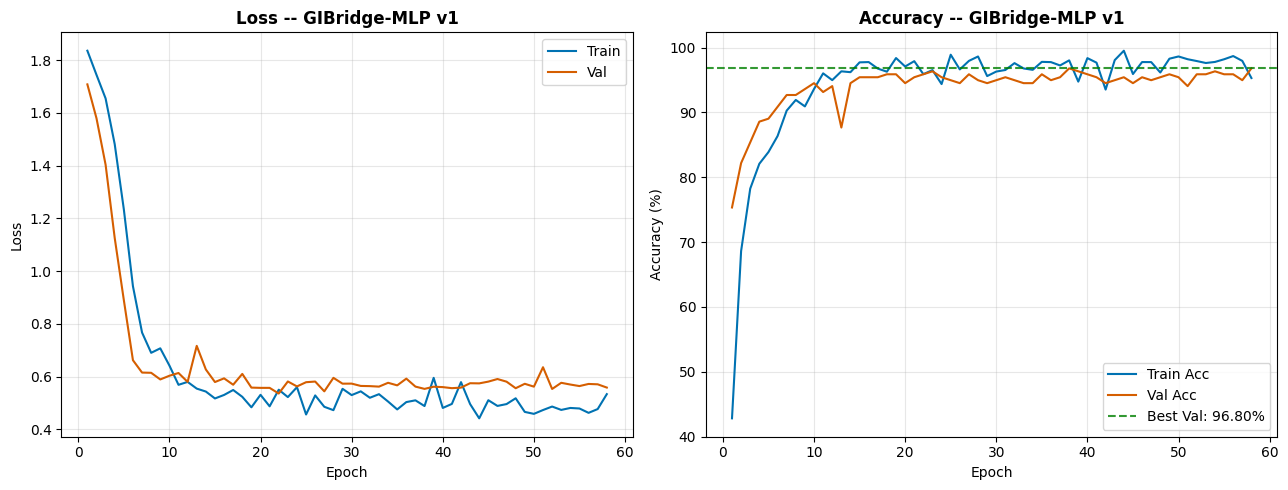

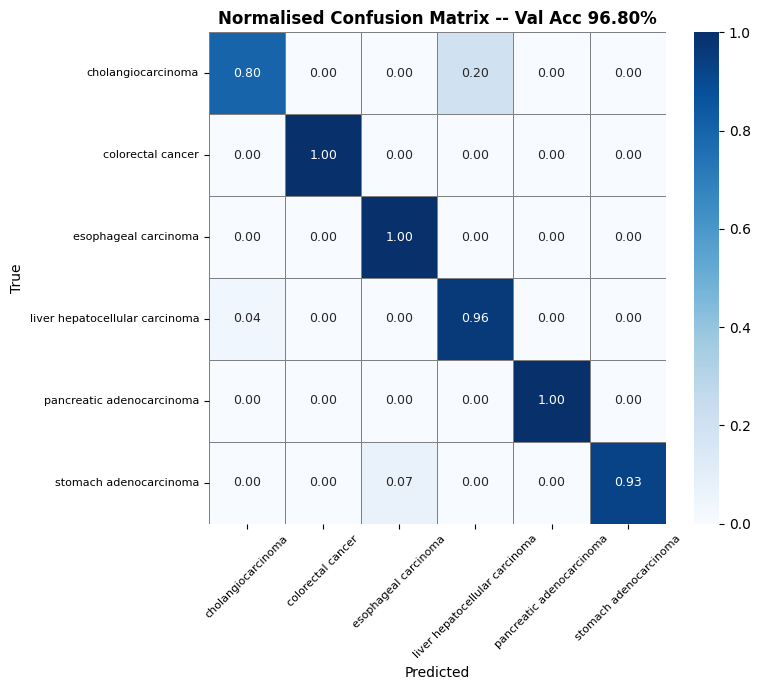

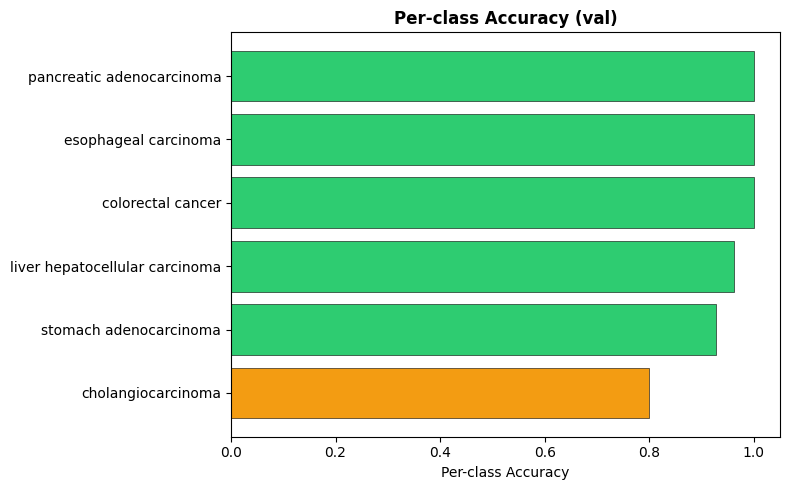


Classes below 70% accuracy: []


In [10]:
# -- Learning curves ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
er = range(1, len(history['train_loss']) + 1)

axes[0].plot(er, history['train_loss'], label='Train', color='#0072B2', linewidth=1.5)
axes[0].plot(er, history['val_loss'],   label='Val',   color='#D55E00', linewidth=1.5)
axes[0].set_title('Loss -- GIBridge-MLP v1', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(er, history['train_acc'], label='Train Acc', color='#0072B2', linewidth=1.5)
axes[1].plot(er, history['val_acc'],   label='Val Acc',   color='#D55E00', linewidth=1.5)
axes[1].axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.8,
                label=f'Best Val: {best_val_acc:.2f}%')
axes[1].set_title('Accuracy -- GIBridge-MLP v1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gibridge_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Confusion matrix (validation) --------------------------------------------
model.eval()
preds_cm, labels_cm = [], []
with torch.no_grad():
    for mrna, cnv, mut, meth, labels in val_loader:
        with torch.cuda.amp.autocast(enabled=CONFIG['use_amp']):
            out = model(mrna.to(DEVICE), cnv.to(DEVICE), mut.to(DEVICE), meth.to(DEVICE))
        preds_cm.extend(out.argmax(1).cpu().numpy())
        labels_cm.extend(labels.numpy())

cm = confusion_matrix(labels_cm, preds_cm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5, linecolor='gray', annot_kws={'size': 9})
ax.set_title(f'Normalised Confusion Matrix -- Val Acc {best_val_acc:.2f}%',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('gibridge_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Per-class accuracy --------------------------------------------------------
per_class_acc = cm_norm.diagonal()
sorted_idx = np.argsort(per_class_acc)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v < 0.70 else '#f39c12' if v < 0.85 else '#2ecc71'
          for v in per_class_acc[sorted_idx]]
ax.barh([le.classes_[i] for i in sorted_idx], per_class_acc[sorted_idx],
        color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlabel('Per-class Accuracy'); ax.set_title('Per-class Accuracy (val)', fontweight='bold')
plt.tight_layout()
plt.savefig('gibridge_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nClasses below 70% accuracy: '
      f'{[le.classes_[i] for i in np.where(per_class_acc < 0.70)[0]]}')


In [11]:
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
te_str     = f'{te_acc:.2f}%' if test_loader is not None else 'N/A'
te_mf1_str = f'{te_mf1:.4f}'  if test_loader is not None else 'N/A'

print('=' * 72)
print('  FINAL RESULTS -- GIBridge-MLP v1 (GI cancer subtype classifier)')
print('=' * 72)
print(f'  Modalities:     mRNA + CNV + Mutation + Methylation (4-way)')
print(f'  Gene counts:    {gene_k}')
print(f'  Classes:        {CONFIG["num_classes"]}  ({list(le.classes_)})')
print(f'  Parameters:     {n_params:,}')
print(f'  Architecture:   embed={CONFIG["embed_dim"]} | per-modality MLP | concat fusion')
print()
print(f'  Val Accuracy:    {best_val_acc:.2f}%')
print(f'  Val Weighted F1: {val_wf1:.4f}')
print(f'  Val Macro F1:    {val_mf1:.4f}')
print(f'  Val MCC:         {val_mcc:.4f}')
print(f'  Test Accuracy:   {te_str}')
print(f'  Test Macro F1:   {te_mf1_str}')
print()
print('  Reference only -- NOT a fair comparison (different task/data/class count):')
print('  ---------------------------------------------------------------------')
print('  Model                   Acc       Classes  Params        Notes')
print('  ---------------------------------------------------------------------')
print(f'  GIBridge-MLP v1 (ours) {best_val_acc:>7.2f}%   {CONFIG["num_classes"]}        '
      f'{n_params:>10,}   6 GI classes, MLP fusion')
print('  OncoBridge-MMCAT v7     95.74%   22       much larger    Pan-cancer, transformer')
print('  ---------------------------------------------------------------------')
print()
print('  Next step: GI-specific drug response prediction (Stage 2)')
print('  -> Reuse this trained encoder as the patient module')
print('  -> Add drug module (Morgan/ECFP4 fingerprints + MLP) for ~10 GI drugs')
print('  -> Concatenate [patient_embed | drug_embed] -> IC50 regression')
print('  -> Rank predicted IC50 per patient to produce top-k drug recommendations')
print('=' * 72)


  FINAL RESULTS -- GIBridge-MLP v1 (GI cancer subtype classifier)
  Modalities:     mRNA + CNV + Mutation + Methylation (4-way)
  Gene counts:    {'mrna': 4000, 'cnv': 1750, 'mut': 1250, 'meth': 3000}
  Classes:        6  (['cholangiocarcinoma', 'colorectal cancer', 'esophageal carcinoma', 'liver hepatocellular carcinoma', 'pancreatic adenocarcinoma', 'stomach adenocarcinoma'])
  Parameters:     2,871,702
  Architecture:   embed=128 | per-modality MLP | concat fusion

  Val Accuracy:    96.80%
  Val Weighted F1: 0.9689
  Val Macro F1:    0.9319
  Val MCC:         0.9601
  Test Accuracy:   96.35%
  Test Macro F1:   0.9425

  Reference only -- NOT a fair comparison (different task/data/class count):
  ---------------------------------------------------------------------
  Model                   Acc       Classes  Params        Notes
  ---------------------------------------------------------------------
  GIBridge-MLP v1 (ours)   96.80%   6         2,871,702   6 GI classes, MLP fusion
 

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from itertools import combinations

class_names = list(le.classes_)
n_classes   = len(class_names)

# Use test split if it exists, else fall back to val
eval_split_key = 'te' if te_idx is not None else 'vl'
eval_idx       = te_idx if te_idx is not None else vl_idx
eval_probs     = te_probs if test_loader is not None else val_probs

model.load_state_dict(best_state)   # make sure we're on the best checkpoint
base_model = model.module if isinstance(model, nn.DataParallel) else model
base_model.eval()

print(f'Using "{eval_split_key}" split for both diagnostics below ({len(eval_idx)} samples)')

Using "te" split for both diagnostics below (219 samples)


In [13]:
print('One-vs-Rest AUROC per class (main 6-class model, held-out split):')
print('=' * 60)
y_eval = y[eval_idx]
for i, cls in enumerate(class_names):
    y_binary = (y_eval == i).astype(int)
    if y_binary.sum() == 0 or y_binary.sum() == len(y_binary):
        print(f'  {cls:<35} AUROC=N/A (no positive/negative samples)')
        continue
    auc = roc_auc_score(y_binary, eval_probs[:, i])
    print(f'  {cls:<35} AUROC={auc:.4f}')
print('=' * 60)

One-vs-Rest AUROC per class (main 6-class model, held-out split):
  cholangiocarcinoma                  AUROC=0.9984
  colorectal cancer                   AUROC=1.0000
  esophageal carcinoma                AUROC=0.9889
  liver hepatocellular carcinoma      AUROC=0.9998
  pancreatic adenocarcinoma           AUROC=1.0000
  stomach adenocarcinoma              AUROC=0.9846


In [14]:
def get_split_arrays(split_key):
    key_map = {'tr': 0, 'vl': 1, 'te': 2}
    ki = key_map[split_key]
    idx_map = {'tr': tr_idx, 'vl': vl_idx, 'te': te_idx}
    idx = idx_map[split_key]

    def get(mod):
        arr = Xp[mod][ki]
        if arr is None:
            arr = Xp[mod][1]
        return arr

    return (get('mrna'), get('cnv'), get('mut'), get('meth'), y[idx])


def extract_embeddings(mrna, cnv, mut, meth, batch_size=64):
    embs = []
    n = mrna.shape[0]
    mrna_t = torch.FloatTensor(mrna)
    cnv_t  = torch.FloatTensor(cnv)
    mut_t  = torch.FloatTensor(mut)
    meth_t = torch.FloatTensor(meth)
    with torch.no_grad():
        for i in range(0, n, batch_size):
            e_m = base_model.mrna_enc(mrna_t[i:i+batch_size].to(DEVICE))
            e_c = base_model.cnv_enc(cnv_t[i:i+batch_size].to(DEVICE))
            e_u = base_model.mut_enc(mut_t[i:i+batch_size].to(DEVICE))
            e_e = base_model.meth_enc(meth_t[i:i+batch_size].to(DEVICE))
            combined = torch.cat([e_m, e_c, e_u, e_e], dim=-1)
            embs.append(combined.cpu().numpy())
    return np.concatenate(embs, axis=0)


mrna_tr, cnv_tr, mut_tr, meth_tr, y_tr_arr = get_split_arrays('tr')
mrna_ev, cnv_ev, mut_ev, meth_ev, y_ev_arr = get_split_arrays(eval_split_key)

emb_tr = extract_embeddings(mrna_tr, cnv_tr, mut_tr, meth_tr)
emb_ev = extract_embeddings(mrna_ev, cnv_ev, mut_ev, meth_ev)

print(f'Extracted embeddings: train={emb_tr.shape} | {eval_split_key}={emb_ev.shape}')

Extracted embeddings: train=(1019, 512) | te=(219, 512)


In [15]:
ovo_results = {}
n_pairs = n_classes * (n_classes - 1) // 2
print(f'Training {n_pairs} one-vs-one probes on frozen Stage 1 embeddings...')
print('=' * 88)

for ci, cj in combinations(range(n_classes), 2):
    name_i, name_j = class_names[ci], class_names[cj]

    tr_mask = np.isin(y_tr_arr, [ci, cj])
    ev_mask = np.isin(y_ev_arr, [ci, cj])

    Xtr_pair, ytr_pair = emb_tr[tr_mask], y_tr_arr[tr_mask]
    Xev_pair, yev_pair = emb_ev[ev_mask], y_ev_arr[ev_mask]

    if len(np.unique(ytr_pair)) < 2 or len(np.unique(yev_pair)) < 2:
        print(f'  [{name_i} vs {name_j}] skipped -- not enough samples in one split')
        continue

    clf = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0)
    clf.fit(Xtr_pair, ytr_pair)
    acc = clf.score(Xev_pair, yev_pair)

    pos_col = list(clf.classes_).index(ci)
    auc = roc_auc_score((yev_pair == ci).astype(int), clf.predict_proba(Xev_pair)[:, pos_col])

    ovo_results[(name_i, name_j)] = {
        'acc': acc, 'auc': auc, 'n_train': len(ytr_pair), 'n_eval': len(yev_pair)
    }
    print(f'  [{name_i:<32} vs {name_j:<32}] acc={acc*100:5.1f}% | AUROC={auc:.3f} | '
          f'n_train={len(ytr_pair):3d} n_eval={len(yev_pair):3d}')

print('=' * 88)

Training 15 one-vs-one probes on frozen Stage 1 embeddings...
  [cholangiocarcinoma               vs colorectal cancer               ] acc=100.0% | AUROC=1.000 | n_train=275 n_eval= 59
  [cholangiocarcinoma               vs esophageal carcinoma            ] acc=100.0% | AUROC=1.000 | n_train=152 n_eval= 33
  [cholangiocarcinoma               vs liver hepatocellular carcinoma  ] acc= 94.9% | AUROC=0.991 | n_train=268 n_eval= 59
  [cholangiocarcinoma               vs pancreatic adenocarcinoma       ] acc=100.0% | AUROC=1.000 | n_train=142 n_eval= 31
  [cholangiocarcinoma               vs stomach adenocarcinoma          ] acc=100.0% | AUROC=1.000 | n_train=282 n_eval= 61
  [colorectal cancer                vs esophageal carcinoma            ] acc= 98.8% | AUROC=0.999 | n_train=377 n_eval= 80
  [colorectal cancer                vs liver hepatocellular carcinoma  ] acc=100.0% | AUROC=1.000 | n_train=493 n_eval=106
  [colorectal cancer                vs pancreatic adenocarcinoma       ] acc=

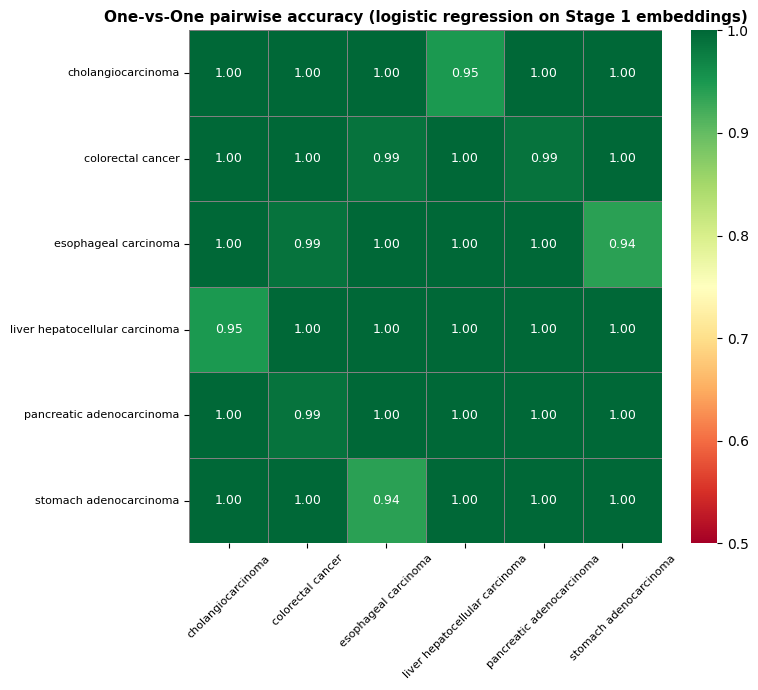

Hardest pair to separate: esophageal carcinoma vs stomach adenocarcinoma (acc=93.9%, AUROC=0.976)


In [16]:
ovo_matrix = np.full((n_classes, n_classes), np.nan)
for (name_i, name_j), res in ovo_results.items():
    i, j = class_names.index(name_i), class_names.index(name_j)
    ovo_matrix[i, j] = res['acc']
    ovo_matrix[j, i] = res['acc']
np.fill_diagonal(ovo_matrix, 1.0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(ovo_matrix, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor='gray', annot_kws={'size': 9})
ax.set_title('One-vs-One pairwise accuracy (logistic regression on Stage 1 embeddings)',
             fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig('gibridge_ovo_pairwise_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

hardest = min(ovo_results.items(), key=lambda kv: kv[1]['acc'])
print(f'Hardest pair to separate: {hardest[0][0]} vs {hardest[0][1]} '
      f'(acc={hardest[1]["acc"]*100:.1f}%, AUROC={hardest[1]["auc"]:.3f})')

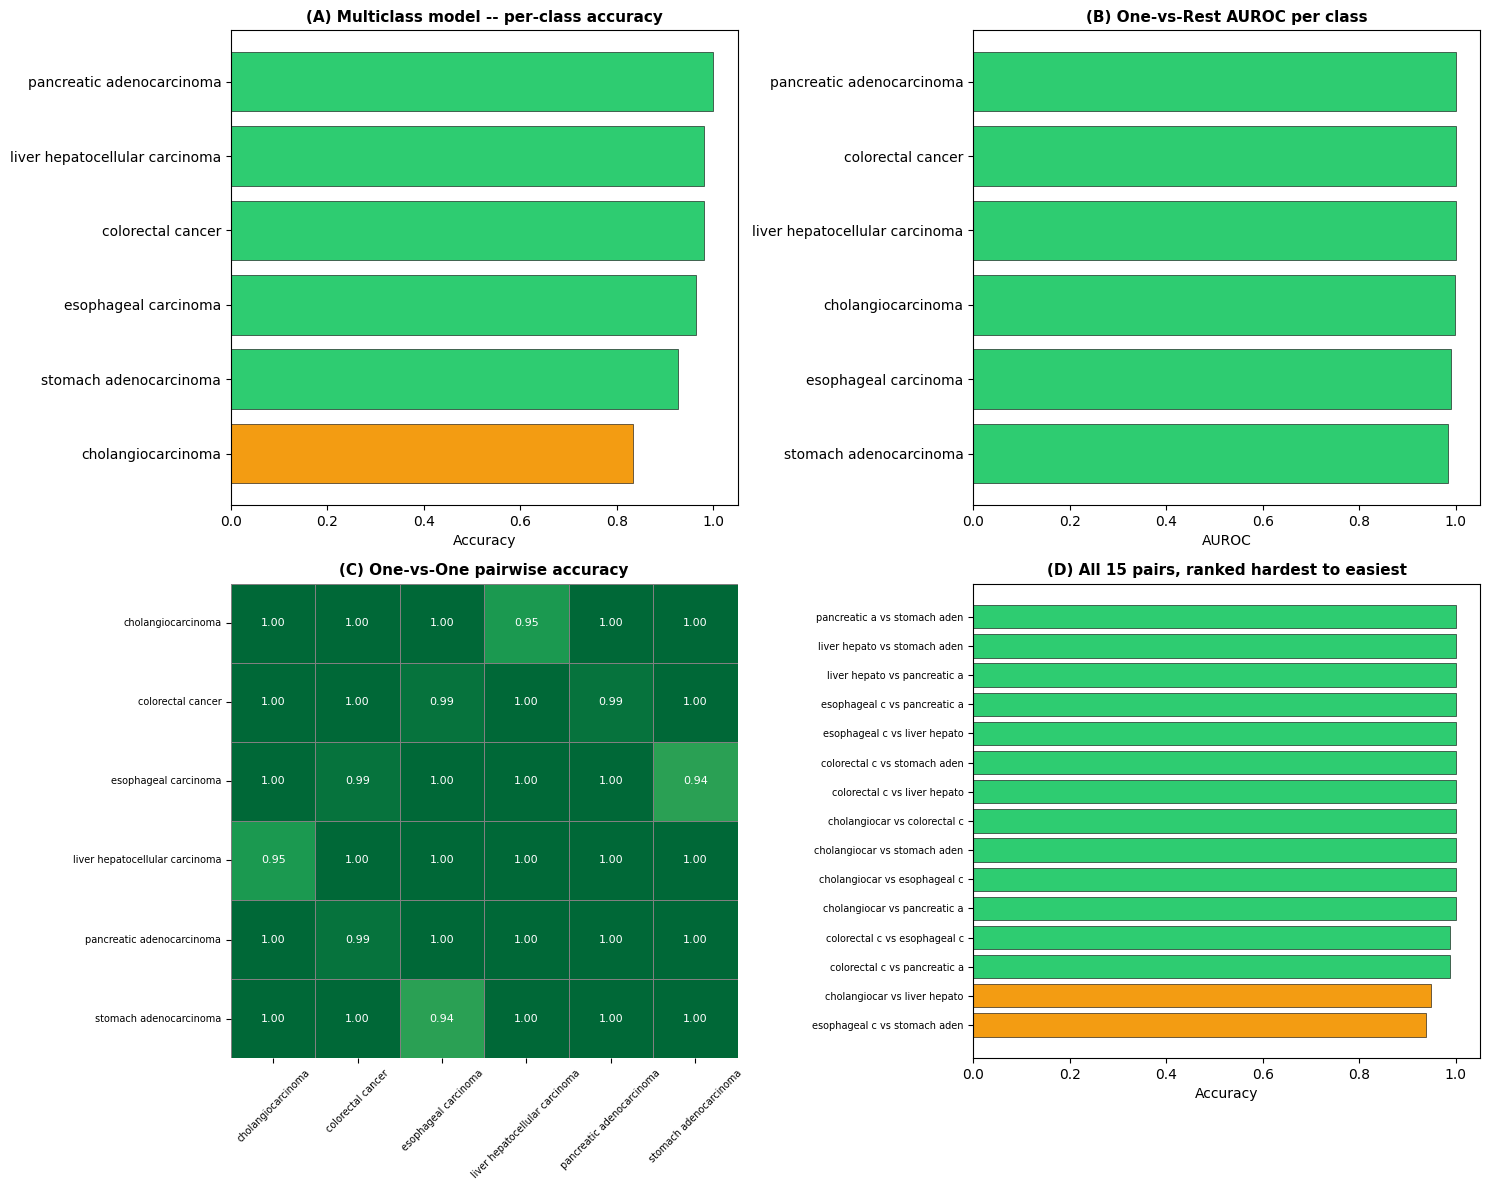

Summary:
  Multiclass overall accuracy (te):  96.35%
  Mean per-class accuracy:                          94.76%
  Mean OvR AUROC:                                   0.9953
  Mean OvO pairwise accuracy:                       99.09%
  Easiest pair:  pancreatic a vs stomach aden  (acc=100.0%)
  Hardest pair:  esophageal c vs stomach aden  (acc=93.9%)


In [17]:
# ============================================================================
# CELL F -- final comparison panel: multiclass vs OvR vs OvO, side by side
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- (1) Per-class accuracy: main multiclass model -------------------------
ax = axes[0, 0]
preds_eval = eval_probs.argmax(1)
per_class_acc_eval = np.array([
    (preds_eval[y_eval == i] == i).mean() if (y_eval == i).sum() > 0 else np.nan
    for i in range(n_classes)
])
order = np.argsort(per_class_acc_eval)
colors = ['#e74c3c' if v < 0.70 else '#f39c12' if v < 0.85 else '#2ecc71'
          for v in per_class_acc_eval[order]]
ax.barh([class_names[i] for i in order], per_class_acc_eval[order],
        color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy')
ax.set_title('(A) Multiclass model -- per-class accuracy', fontweight='bold', fontsize=11)

# --- (2) One-vs-Rest AUROC per class ----------------------------------------
ax = axes[0, 1]
ovr_aucs = []
for i, cls in enumerate(class_names):
    y_binary = (y_eval == i).astype(int)
    if y_binary.sum() == 0 or y_binary.sum() == len(y_binary):
        ovr_aucs.append(np.nan)
    else:
        ovr_aucs.append(roc_auc_score(y_binary, eval_probs[:, i]))
ovr_aucs = np.array(ovr_aucs)
order = np.argsort(ovr_aucs)
colors = ['#e74c3c' if v < 0.80 else '#f39c12' if v < 0.95 else '#2ecc71'
          for v in ovr_aucs[order]]
ax.barh([class_names[i] for i in order], ovr_aucs[order],
        color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlim(0, 1.05)
ax.set_xlabel('AUROC')
ax.set_title('(B) One-vs-Rest AUROC per class', fontweight='bold', fontsize=11)

# --- (3) One-vs-One pairwise accuracy matrix --------------------------------
ax = axes[1, 0]
sns.heatmap(ovo_matrix, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor='gray', annot_kws={'size': 8}, cbar=False)
ax.set_title('(C) One-vs-One pairwise accuracy', fontweight='bold', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

# --- (4) Ranked bar: hardest to easiest pairs -------------------------------
ax = axes[1, 1]
pair_labels = [f'{i}\nvs\n{j}' for i, j in ovo_results.keys()]
pair_accs   = [v['acc'] for v in ovo_results.values()]
order = np.argsort(pair_accs)
pair_labels_sorted = [f'{k[0][:12]} vs {k[1][:12]}' for k in
                       [list(ovo_results.keys())[i] for i in order]]
pair_accs_sorted = [pair_accs[i] for i in order]
colors = ['#e74c3c' if v < 0.80 else '#f39c12' if v < 0.95 else '#2ecc71'
          for v in pair_accs_sorted]
ax.barh(range(len(pair_accs_sorted)), pair_accs_sorted, color=colors,
        edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(pair_labels_sorted)))
ax.set_yticklabels(pair_labels_sorted, fontsize=7)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy')
ax.set_title('(D) All 15 pairs, ranked hardest to easiest', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('gibridge_full_comparison_panel.png', dpi=150, bbox_inches='tight')
plt.show()

print('Summary:')
print(f'  Multiclass overall accuracy ({eval_split_key}):  {(preds_eval == y_eval).mean()*100:.2f}%')
print(f'  Mean per-class accuracy:                          {np.nanmean(per_class_acc_eval)*100:.2f}%')
print(f'  Mean OvR AUROC:                                   {np.nanmean(ovr_aucs):.4f}')
print(f'  Mean OvO pairwise accuracy:                       {np.mean(pair_accs)*100:.2f}%')
print(f'  Easiest pair:  {pair_labels_sorted[-1]}  (acc={pair_accs_sorted[-1]*100:.1f}%)')
print(f'  Hardest pair:  {pair_labels_sorted[0]}  (acc={pair_accs_sorted[0]*100:.1f}%)')

In [18]:
class ModalityMLPEncoderNoGate(nn.Module):
    """Same as ModalityMLPEncoder but skips the GeneImportanceLayer gate."""
    def __init__(self, num_genes, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_genes, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.BatchNorm1d(embed_dim), nn.GELU(), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class ModalityMLPEncoderShallow(nn.Module):
    """Single linear layer per modality -- no hidden layer."""
    def __init__(self, num_genes, embed_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_genes, embed_dim), nn.BatchNorm1d(embed_dim), nn.GELU(), nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class GIBridgeMLP_NoGate(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        E, H, D = cfg['embed_dim'], cfg['hidden_dim'], cfg['dropout']
        self.mrna_enc = ModalityMLPEncoderNoGate(cfg['num_mrna_genes'], E, H, D)
        self.cnv_enc  = ModalityMLPEncoderNoGate(cfg['num_cnv_genes'],  E, H, D)
        self.mut_enc  = ModalityMLPEncoderNoGate(cfg['num_mut_genes'],  E, H, D)
        self.meth_enc = ModalityMLPEncoderNoGate(cfg['num_meth_genes'], E, H, D)
        self.classifier = nn.Sequential(
            nn.LayerNorm(E * 4), nn.Linear(E * 4, E * 2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E * 2, E), nn.GELU(), nn.Dropout(D), nn.Linear(E, cfg['num_classes']),
        )

    def forward(self, mrna, cnv, mut, meth):
        e = torch.cat([self.mrna_enc(mrna), self.cnv_enc(cnv),
                        self.mut_enc(mut), self.meth_enc(meth)], dim=-1)
        return self.classifier(e)


class GIBridgeMLP_Shallow(nn.Module):
    """Single linear layer per modality + single linear classifier -- weakest neural variant."""
    def __init__(self, cfg):
        super().__init__()
        E, D = cfg['embed_dim'], cfg['dropout']
        self.mrna_enc = ModalityMLPEncoderShallow(cfg['num_mrna_genes'], E, D)
        self.cnv_enc  = ModalityMLPEncoderShallow(cfg['num_cnv_genes'],  E, D)
        self.mut_enc  = ModalityMLPEncoderShallow(cfg['num_mut_genes'],  E, D)
        self.meth_enc = ModalityMLPEncoderShallow(cfg['num_meth_genes'], E, D)
        self.classifier = nn.Sequential(nn.LayerNorm(E * 4), nn.Linear(E * 4, cfg['num_classes']))

    def forward(self, mrna, cnv, mut, meth):
        e = torch.cat([self.mrna_enc(mrna), self.cnv_enc(cnv),
                        self.mut_enc(mut), self.meth_enc(meth)], dim=-1)
        return self.classifier(e)


class MRNAOnlyMLP(nn.Module):
    """Same per-modality encoder as the full model (with gate), but mRNA only -- tests modality count."""
    def __init__(self, cfg):
        super().__init__()
        E, H, D = cfg['embed_dim'], cfg['hidden_dim'], cfg['dropout']
        self.mrna_enc = ModalityMLPEncoder(cfg['num_mrna_genes'], E, H, D, cfg['gate_init'])
        self.classifier = nn.Sequential(
            nn.LayerNorm(E), nn.Linear(E, E // 2), nn.GELU(), nn.Dropout(D),
            nn.Linear(E // 2, cfg['num_classes']),
        )

    def forward(self, mrna):
        return self.classifier(self.mrna_enc(mrna))


def train_ablation_model(model, model_name, get_batch_fn, max_epochs=80, patience=12, lr=3e-4):
    """
    Generic trainer for ablation models. Reuses the existing train/val/test loaders.
    get_batch_fn(batch) -> (inputs_tuple, labels); inputs_tuple is unpacked into model(*inputs_tuple).
    """
    model = model.to(DEVICE)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=CONFIG['weight_decay'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    crit  = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=CONFIG['label_smoothing'])

    best_acc, best_state, patience_cnt = 0.0, None, 0
    epoch = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch in train_loader:
            inputs, labels = get_batch_fn(batch)
            labels = labels.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            out  = model(*inputs)
            loss = crit(out, labels)
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for batch in val_loader:
                inputs, labels = get_batch_fn(batch)
                labels = labels.to(DEVICE)
                out = model(*inputs)
                correct += (out.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_acc = 100.0 * correct / total

        if val_acc > best_acc:
            best_acc, best_state, patience_cnt = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    eval_loader = test_loader if test_loader is not None else val_loader
    correct = total = 0
    with torch.no_grad():
        for batch in eval_loader:
            inputs, labels = get_batch_fn(batch)
            labels = labels.to(DEVICE)
            out = model(*inputs)
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
    test_acc = 100.0 * correct / total

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [{model_name:<28}] best_val={best_acc:5.2f}% | test={test_acc:5.2f}% | '
          f'epochs_run={epoch} | params={n_params:,}')
    return {'model_name': model_name, 'val_acc': best_acc, 'test_acc': test_acc,
            'params': n_params, 'epochs': epoch}

In [19]:
def get_batch_4mod(batch):
    mrna, cnv, mut, meth, labels = batch
    return (mrna.to(DEVICE), cnv.to(DEVICE), mut.to(DEVICE), meth.to(DEVICE)), labels

def get_batch_mrna_only(batch):
    mrna, cnv, mut, meth, labels = batch
    return (mrna.to(DEVICE),), labels

print('Training ablation models on the same splits, gene selection, and class weights...')
print('=' * 88)

ablation_results = []
ablation_results.append(
    train_ablation_model(GIBridgeMLP_NoGate(CONFIG), 'No gene gate', get_batch_4mod))
ablation_results.append(
    train_ablation_model(GIBridgeMLP_Shallow(CONFIG), 'Shallow encoder', get_batch_4mod))
ablation_results.append(
    train_ablation_model(MRNAOnlyMLP(CONFIG), 'mRNA only', get_batch_mrna_only))

print('=' * 88)

Training ablation models on the same splits, gene selection, and class weights...
  [No gene gate                ] best_val=96.80% | test=95.89% | epochs_run=27 | params=2,861,702
  [Shallow encoder             ] best_val=95.89% | test=96.35% | epochs_run=26 | params=1,285,638
  [mRNA only                   ] best_val=95.89% | test=95.43% | epochs_run=16 | params=1,070,822


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

def build_concat_features(split_key):
    key_map = {'tr': 0, 'vl': 1, 'te': 2}
    ki = key_map[split_key]
    idx_map = {'tr': tr_idx, 'vl': vl_idx, 'te': te_idx}
    idx = idx_map[split_key]

    def get(mod):
        arr = Xp[mod][ki]
        return arr if arr is not None else Xp[mod][1]

    return np.concatenate([get('mrna'), get('cnv'), get('mut'), get('meth')], axis=1), y[idx]


eval_key = 'te' if te_idx is not None else 'vl'
Xc_tr, yc_tr = build_concat_features('tr')
Xc_ev, yc_ev = build_concat_features(eval_key)

print('Training classical ML baselines on concatenated multi-omics features...')
print('=' * 88)

lr_clf = LogisticRegression(max_iter=3000, class_weight='balanced', C=1.0)
lr_clf.fit(Xc_tr, yc_tr)
lr_acc = lr_clf.score(Xc_ev, yc_ev) * 100
lr_params = Xc_tr.shape[1] * n_classes
print(f'  [{"Logistic regression":<28}] test={lr_acc:5.2f}% | params~{lr_params:,} (linear only)')
ablation_results.append({'model_name': 'Logistic regression (linear)', 'val_acc': np.nan,
                          'test_acc': lr_acc, 'params': lr_params, 'epochs': None})

rf_clf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                                 random_state=CONFIG['seed'], n_jobs=-1)
rf_clf.fit(Xc_tr, yc_tr)
rf_acc = rf_clf.score(Xc_ev, yc_ev) * 100
print(f'  [{"Random forest":<28}] test={rf_acc:5.2f}% | non-neural, tree-based')
ablation_results.append({'model_name': 'Random forest (non-neural)', 'val_acc': np.nan,
                          'test_acc': rf_acc, 'params': None, 'epochs': None})

print('=' * 88)

Training classical ML baselines on concatenated multi-omics features...
  [Logistic regression         ] test=96.35% | params~60,000 (linear only)
  [Random forest               ] test=93.61% | non-neural, tree-based


Model                          |  Val Acc |  Test Acc |       Params
--------------------------------------------------------------------
GIBridge-MLP (full)            |   96.80% |    96.35% |    2,871,702
No gene gate                   |   96.80% |    95.89% |    2,861,702
Shallow encoder                |   95.89% |    96.35% |    1,285,638
mRNA only                      |   95.89% |    95.43% |    1,070,822
Logistic regression (linear)   |      n/a |    96.35% |       60,000
Random forest (non-neural)     |      n/a |    93.61% |          n/a


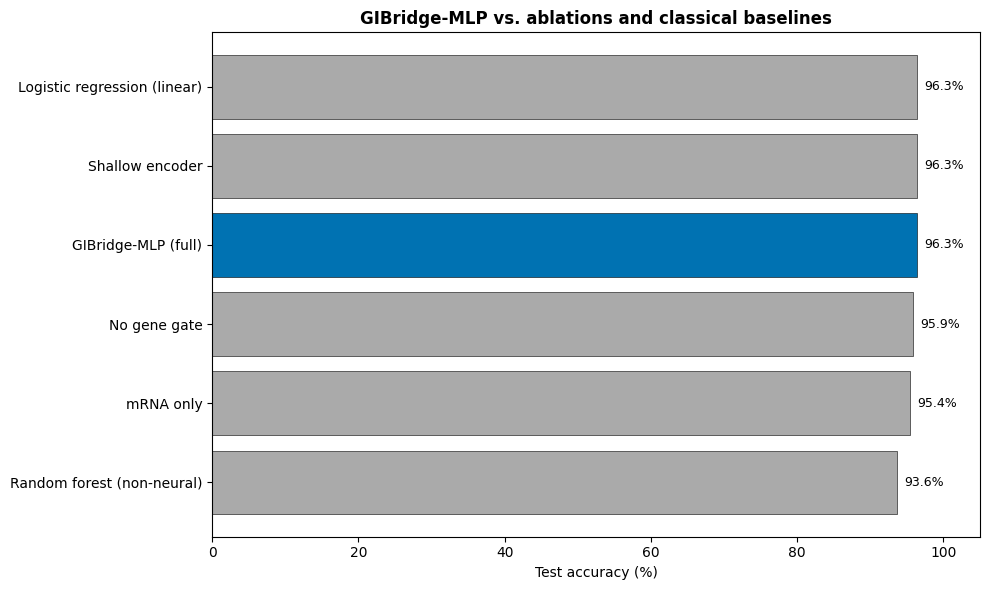

In [21]:
all_results = [{'model_name': 'GIBridge-MLP (full)', 'val_acc': best_val_acc,
                 'test_acc': te_acc if test_loader is not None else np.nan,
                 'params': n_params, 'epochs': None}] + ablation_results

print(f'{"Model":<30} | {"Val Acc":>8} | {"Test Acc":>9} | {"Params":>12}')
print('-' * 68)
for r in all_results:
    val_str = f'{r["val_acc"]:.2f}%' if not (isinstance(r['val_acc'], float) and np.isnan(r['val_acc'])) else 'n/a'
    par_str = f'{r["params"]:,}' if r['params'] is not None else 'n/a'
    print(f'{r["model_name"]:<30} | {val_str:>8} | {r["test_acc"]:>8.2f}% | {par_str:>12}')

fig, ax = plt.subplots(figsize=(10, 6))
names = [r['model_name'] for r in all_results]
accs  = [r['test_acc'] for r in all_results]
order = np.argsort(accs)
colors = ['#0072B2' if names[i] == 'GIBridge-MLP (full)' else '#AAAAAA' for i in order]
ax.barh([names[i] for i in order], [accs[i] for i in order], color=colors,
        edgecolor='black', linewidth=0.4)
ax.set_xlabel('Test accuracy (%)')
ax.set_title('GIBridge-MLP vs. ablations and classical baselines', fontweight='bold')
ax.set_xlim(0, 105)
for i, idx in enumerate(order):
    ax.text(accs[idx] + 1, i, f'{accs[idx]:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('gibridge_ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()